In [10]:
# Import necessary libraries
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np


from tensorflow import keras
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR, SVC
from math import sqrt
from sklearn.model_selection import train_test_split, ShuffleSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [37]:
# Main Dataset Exploration(transport.csv) and Preprocessing

# Read the data from the CSV file
df = pd.read_csv("transport.csv", skiprows=1)
df.set_index("STATE", inplace=True)

# List of strings to match in column names
strings_to_match = ["FATAL", "SERIOUS", "MINOR", "TOTAL CASES", "NUMBER INJURED", "NUMBER KILLED", "TOTAL CASUALTY", "PEOPLE INVOLVED"]

# Calculate the sum for each string in the specified columns and merge the yearly Quarter tables data to a single table
transport_df = pd.DataFrame({string: df.loc[:, df.columns.str.contains(string)].sum(axis=1) for string in strings_to_match})

# Save consolidated dataset by converting transport_df to csv
transport_df.to_csv('transport1.csv', sep=',', index=False, encoding='utf-8')

print("Main Dataset Overview: Severity of Highway Traffic Accidents Across Nigerian States\n")
print(transport_df.info())

# Display summary statistics
print("\nSummary Statistics:")
print(transport_df.describe())

# Check for missing values
print("\nMissing Values:")
print(transport_df.isnull().sum())

# No missing values to handle for the main dataset

# Display the first few rows of the dataset
print("\nFirst Few Rows:")
print(transport_df.head())



Main Dataset Overview: Severity of Highway Traffic Accidents Across Nigerian States

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, Abia to Zamfara
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   FATAL            37 non-null     int64
 1   SERIOUS          37 non-null     int64
 2   MINOR            37 non-null     int64
 3   TOTAL CASES      37 non-null     int64
 4   NUMBER INJURED   37 non-null     int64
 5   NUMBER KILLED    37 non-null     int64
 6   TOTAL CASUALTY   37 non-null     int64
 7   PEOPLE INVOLVED  37 non-null     int64
dtypes: int64(8)
memory usage: 2.6+ KB
None

Summary Statistics:
            FATAL      SERIOUS       MINOR  TOTAL CASES  NUMBER INJURED  \
count   37.000000    37.000000   37.000000    37.000000       37.000000   
mean   239.054054   622.000000  103.702703   964.756757     2795.162162   
std    188.617035   553.944943  165.990439   848.616404     2140.713802   
min  

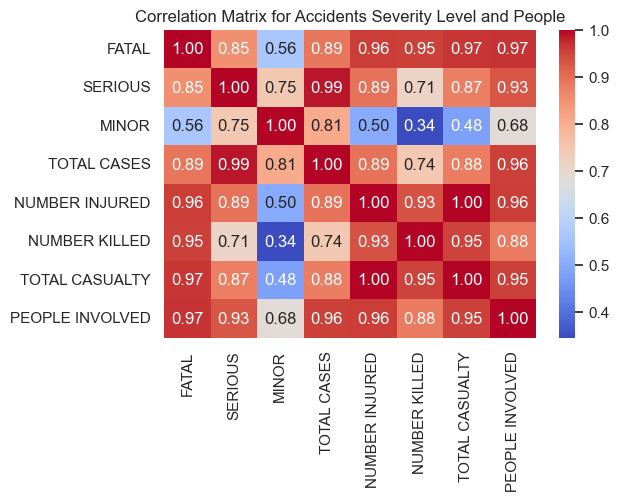

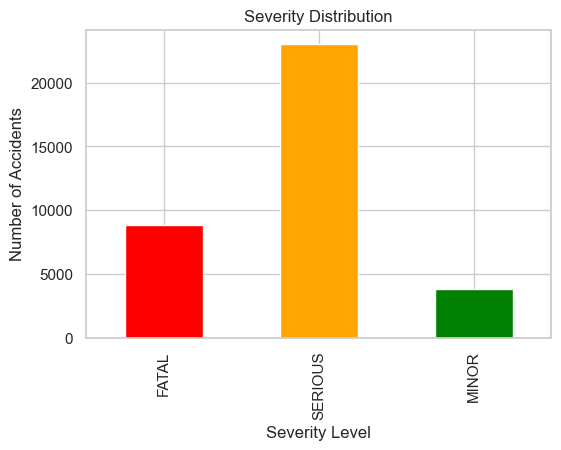

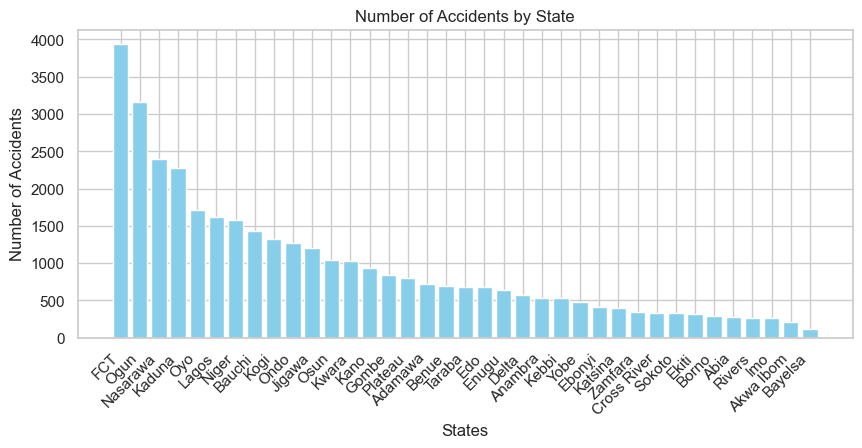

In [12]:
# Main Dataset (transport.csv) Visualization

# Set the style for the plots
sns.set(style="whitegrid")

# Visualize the correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(transport_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Accidents Severity Level and People")
plt.show()

# Severity Distribution
severity_distribution = transport_df[['FATAL', 'SERIOUS', 'MINOR']].sum()
severity_distribution.plot(kind='bar', figsize=(6, 4), color=['red', 'orange', 'green'])
plt.title('Severity Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Number of Accidents')
plt.show()

# Accidents by State
state_incidents = transport_df.groupby('STATE')['TOTAL CASES'].sum().reset_index()

# Bar chart showing the number of accidents in each state
plt.figure(figsize=(10, 4))
state_incidents.sort_values(by='TOTAL CASES', ascending=False, inplace=True)
plt.bar(state_incidents['STATE'], state_incidents['TOTAL CASES'], color='skyblue')
plt.title('Number of Accidents by State')
plt.xlabel('States')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=45, ha='right')
plt.show()


In [38]:
# Complementary Dataset Exploration (causativefactors.csv) and Preprocessing for Augmentation

# Load dataset
cdf = pd.read_csv('causativefactors.csv', skiprows=2)

cdf.set_index("STATE", inplace=True)
# List of strings to match in column names
strings_to_match = ["SPV", "UPD", "TBT", "MDV", "BFL", "OVL", "DOT", "WOT", "DGD", "BRD", "RTV", "OBS", "SOS", "DAD", "PWR", "FTQ", "SLV", "OTHERS", "TOTAL"]

# Calculate the sum for each string in the specified columns
causative_factors_df = pd.DataFrame({string: cdf.loc[:, cdf.columns.str.contains(string)].sum(axis=1) for string in strings_to_match})

# Save consolidated dataset by converting causative_factors_df to csv
causative_factors_df.to_csv('causative_factors1', sep=',', index=False, encoding='utf-8')

# Display basic information about the dataset
print("Complementary Dataset Overview: Causative Factors of Accidents across Nigerian States\n")
print(causative_factors_df.info())

# Display summary statistics
print("\nSummary Statistics:")
print(causative_factors_df.describe())

# Check for missing values
print("\nMissing Values:")
print(causative_factors_df.isnull().sum())

# No missing values to handle for the complementary dataset

# Display the first few rows of the dataset
print("\nFirst Few Rows:")
print(causative_factors_df.head())

Complementary Dataset Overview: Causative Factors of Accidents across Nigerian States

<class 'pandas.core.frame.DataFrame'>
Index: 37 entries, Abia to Zamfara
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   SPV     37 non-null     int64
 1   UPD     37 non-null     int64
 2   TBT     37 non-null     int64
 3   MDV     37 non-null     int64
 4   BFL     37 non-null     int64
 5   OVL     37 non-null     int64
 6   DOT     37 non-null     int64
 7   WOT     37 non-null     int64
 8   DGD     37 non-null     int64
 9   BRD     37 non-null     int64
 10  RTV     37 non-null     int64
 11  OBS     37 non-null     int64
 12  SOS     37 non-null     int64
 13  DAD     37 non-null     int64
 14  PWR     37 non-null     int64
 15  FTQ     37 non-null     int64
 16  SLV     37 non-null     int64
 17  OTHERS  37 non-null     int64
 18  TOTAL   37 non-null     int64
dtypes: int64(19)
memory usage: 5.8+ KB
None

Summary Statistics:
      

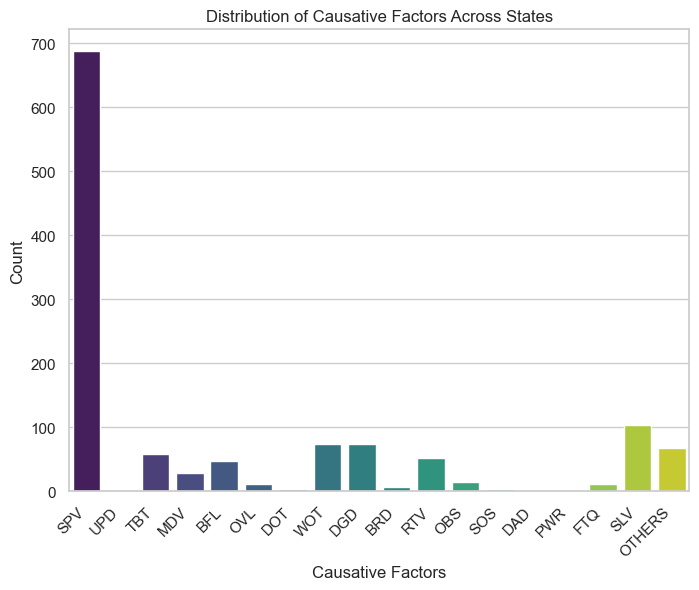

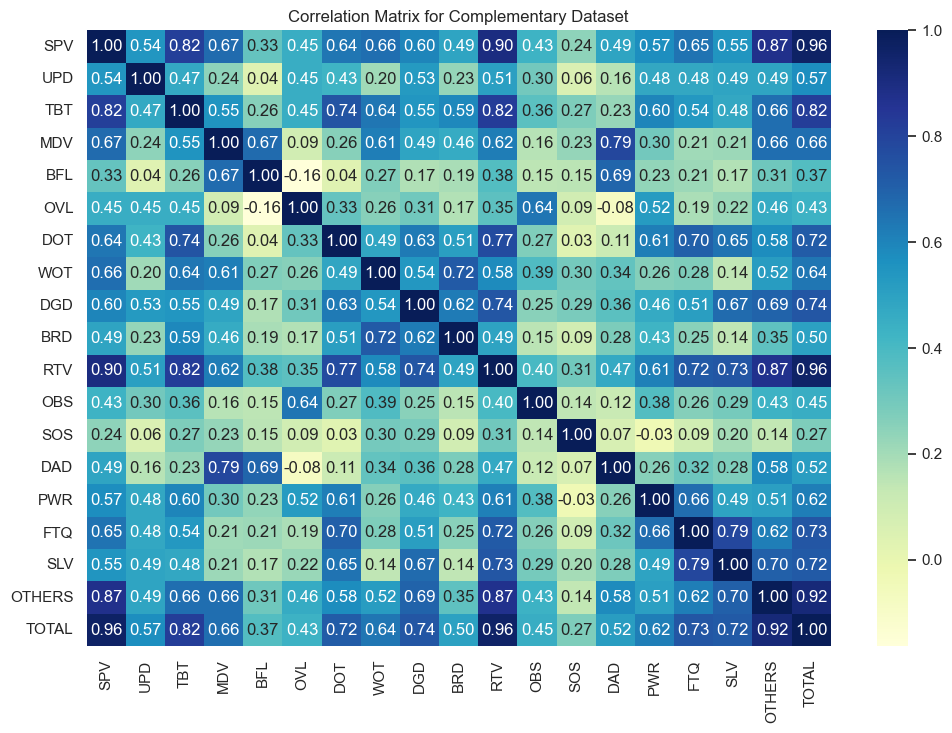

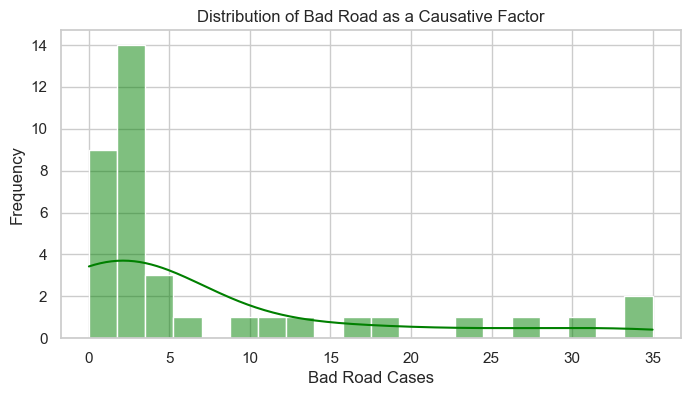

In [14]:
# Complementary Dataset (causativefactors.csv) Visualization

# Set the style for the plots
sns.set(style="whitegrid")

# Visualize the distribution of causative factors across states
plt.figure(figsize=(8, 6))
sns.barplot(data=causative_factors_df.drop("TOTAL", axis=1), errorbar=None, palette="viridis")
plt.title("Distribution of Causative Factors Across States")
plt.xlabel("Causative Factors")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Visualize the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(causative_factors_df.corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Correlation Matrix for Complementary Dataset")
plt.show()

# Visualize the distribution of 'BRD' (Bad Road) in causativefactors.csv
plt.figure(figsize=(8, 4))
sns.histplot(causative_factors_df['BRD'], bins=20, kde=True, color='green')
plt.title('Distribution of Bad Road as a Causative Factor')
plt.xlabel('Bad Road Cases')
plt.ylabel('Frequency')
plt.show()


Merged Dataset:
           FATAL  SERIOUS  MINOR  TOTAL CASES  NUMBER INJURED  NUMBER KILLED  \
STATE                                                                          
Abia          86      149     44          279             961            170   
Adamawa      125      580     21          726            2101            260   
Akwa Ibom     66      121     23          210             428             92   
Anambra      139      281    117          537            1243            198   
Bauchi       447      949     32         1428            5927           1048   

           TOTAL CASUALTY  PEOPLE INVOLVED  SPV  UPD  ...  DGD  BRD  RTV  OBS  \
STATE                                                 ...                       
Abia                 1131             2140  142    0  ...   14    0   20    2   
Adamawa              2361             3922  557    1  ...   34    1   25   68   
Akwa Ibom             520             1072  144    2  ...   18    2    8    0   
Anambra           

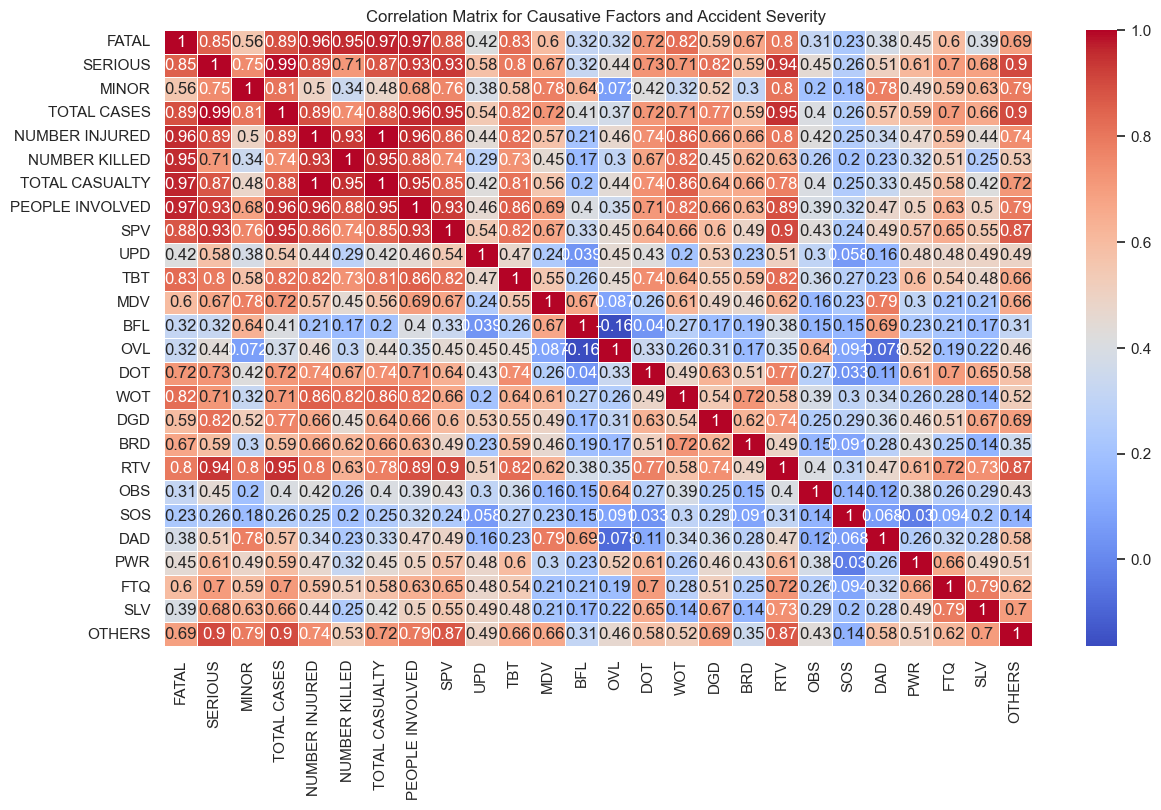

In [25]:
# Data Augmentation for better performance

# Merge transport.csv and causative factors.csv
merged_data = pd.merge(transport_df, causative_factors_df.drop("TOTAL", axis=1), left_index=True, right_index=True)
# Display the merged dataset
print("Merged Dataset:")
print(merged_data.head(5))

# Correlation analysis
correlation_matrix = merged_data.corr()
relevant_features = correlation_matrix['TOTAL CASES'].sort_values(ascending=False).index[1:]
print(relevant_features)

# Define predictors (X) and target variable (y)
X = merged_data.drop(['FATAL', 'SERIOUS', 'MINOR', 'TOTAL CASES', 'NUMBER INJURED', 'NUMBER KILLED', 'TOTAL CASUALTY', 'PEOPLE INVOLVED'], axis=1)
y = merged_data['TOTAL CASUALTY']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train a Random Forest Regressor model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
# Predict on the test set
y_pred = rf_model.predict(X_test)

# Calculate and print metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")
print(f"Mean Absolute Error: {mae}")

# Feature Importance Analysis
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance Scores:")
print(feature_importances)

# Correlation Analysis
correlation_matrix = merged_data.corr()
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title("Correlation Matrix for Causative Factors and Accident Severity ")
plt.show()

# Function to visualize confusion matrix
def plot_confusion(conf_matrix, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

In [26]:
# SVM models with different kernels to predict the total accidents cases quarterly
# SVM Model1

# Extract features (X) and target variable (y) from the merged dataset
X_merged = merged_data.drop("TOTAL CASES", axis=1).values
y_merged = merged_data.loc[:, "TOTAL CASES"].values

# Split the dataset into training and testing sets
X_train_merged, X_test_merged, y_train_merged, y_test_merged = train_test_split(
    X_merged, y_merged, test_size=0.2, random_state=42
)

# Print shapes of training and testing sets
print("Shapes of Training and Testing Sets:")
print("X_train_merged:", X_train_merged.shape)
print("X_test_merged:", X_test_merged.shape)
print("y_train_merged:", y_train_merged.shape)
print("y_test_merged:", y_test_merged.shape)

# Create SVM models with different kernels
svm_linear_model = SVR(kernel='linear', C=1)
svm_rbf_model = SVR(kernel='rbf', C=1)
svm_poly_model = SVR(kernel='poly', degree=3, C=1)

# Train the models on the training set
svm_linear_model.fit(X_train_merged, y_train_merged)
svm_rbf_model.fit(X_train_merged, y_train_merged)
svm_poly_model.fit(X_train_merged, y_train_merged)

# Predict on the testing set
y_pred_linear_svm = svm_linear_model.predict(X_test_merged)
y_pred_rbf_svm = svm_rbf_model.predict(X_test_merged)
y_pred_poly_svm = svm_poly_model.predict(X_test_merged)

# Evaluate the model performance
mse_linear = mean_squared_error(y_test_merged, y_pred_linear_svm)
rmse_linear = sqrt(mse_linear)
r2_linear = r2_score(y_test_merged, y_pred_linear_svm)
mae_linear = mean_absolute_error(y_test_merged, y_pred_linear_svm)

mse_rbf = mean_squared_error(y_test_merged, y_pred_rbf_svm)
rmse_rbf = sqrt(mse_rbf)
r2_rbf = r2_score(y_test_merged, y_pred_rbf_svm)
mae_rbf = mean_absolute_error(y_test_merged, y_pred_rbf_svm)

mse_poly = mean_squared_error(y_test_merged, y_pred_poly_svm)
rmse_poly = sqrt(mse_poly)
r2_poly = r2_score(y_test_merged, y_pred_poly_svm)
mae_poly = mean_absolute_error(y_test_merged, y_pred_poly_svm)

# Baseline prediction
baseline_prediction = np.mean(y_train_merged)

# Baseline metrics
mse_baseline = mean_squared_error(y_test_merged, [baseline_prediction] * len(y_test_merged))
rmse_baseline = sqrt(mse_baseline)
r2_baseline = r2_score(y_test_merged, [baseline_prediction] * len(y_test_merged))
mae_baseline = mean_absolute_error(y_test_merged, [baseline_prediction] * len(y_test_merged))

# Baseline prediction using median
baseline_prediction_median = np.median(y_train_merged)

# Baseline metrics with median
mse_baseline_median = mean_squared_error(y_test_merged, [baseline_prediction_median] * len(y_test_merged))
rmse_baseline_median = sqrt(mse_baseline_median)
r2_baseline_median = r2_score(y_test_merged, [baseline_prediction_median] * len(y_test_merged))
mae_baseline_median = mean_absolute_error(y_test_merged, [baseline_prediction_median] * len(y_test_merged))


# Display the results
print("\nLinear SVM Results:")
print(f"Mean Squared Error: {mse_linear}")
print(f"Root Mean Squared Error: {rmse_linear}")
print(f"R-squared: {r2_linear}")
print(f"Mean Absolute Error: {mae_linear}")

print("\nRBF SVM Results:")
print(f"Mean Squared Error: {mse_rbf}")
print(f"Root Mean Squared Error: {rmse_rbf}")
print(f"R-squared: {r2_rbf}")
print(f"Mean Absolute Error: {mae_rbf}")

print("\nPolynomial SVM Results:")
print(f"Mean Squared Error: {mse_poly}")
print(f"Root Mean Squared Error: {rmse_poly}")
print(f"R-squared: {r2_poly}")
print(f"Mean Absolute Error: {mae_poly}")

# Display baseline results
print("\nBaseline Model Results:")
print(f"Mean Squared Error: {mse_baseline}")
print(f"Root Mean Squared Error: {rmse_baseline}")
print(f"R-squared: {r2_baseline}")
print(f"Mean Absolute Error: {mae_baseline}")

# Display baseline results with median
print("\nBaseline Model Results (using Median):")
print(f"Mean Squared Error: {mse_baseline_median}")
print(f"Root Mean Squared Error: {rmse_baseline_median}")
print(f"R-squared: {r2_baseline_median}")
print(f"Mean Absolute Error: {mae_baseline_median}")


Shapes of Training and Testing Sets:
X_train_merged: (29, 25)
X_test_merged: (8, 25)
y_train_merged: (29,)
y_test_merged: (8,)

Linear SVM Results:
Mean Squared Error: 0.6239680045674906
Root Mean Squared Error: 0.7899164541693574
R-squared: 0.9999981833220866
Mean Absolute Error: 0.6040235092431061

RBF SVM Results:
Mean Squared Error: 709377.3243526114
Root Mean Squared Error: 842.2454062520088
R-squared: -1.0653464729532907
Mean Absolute Error: 631.1023462884423

Polynomial SVM Results:
Mean Squared Error: 503089.81218196766
Root Mean Squared Error: 709.2882433693425
R-squared: -0.4647420117594223
Mean Absolute Error: 533.9978188705048

Baseline Model Results:
Mean Squared Error: 422069.3897146254
Root Mean Squared Error: 649.6686768766256
R-squared: -0.22885169212900047
Mean Absolute Error: 503.4655172413793

Baseline Model Results (using Median):
Mean Squared Error: 719848.75
Root Mean Squared Error: 848.4390078255478
R-squared: -1.0958339459597952
Mean Absolute Error: 636.25


In [28]:
# SVM tuned Model

# Define the parameter grid for linear kernel
param_grid_linear = {'C': [0.1, 1, 10, 100]}

# Create an SVM model with a linear kernel
svm_linear_model = SVR(kernel='linear')

# Perform grid search with cross-validation for linear kernel
grid_search_linear = GridSearchCV(svm_linear_model, param_grid_linear, cv=5)
grid_search_linear.fit(X_train_merged, y_train_merged)

# Get the best hyperparameters for the linear kernel
best_params_linear = grid_search_linear.best_params_

# Create an SVM model with the best hyperparameters for the linear kernel
best_svm_linear_model = SVR(kernel='linear', C=best_params_linear['C'])
best_svm_linear_model.fit(X_train_merged, y_train_merged)

# Evaluate the tuned linear model
y_pred_tuned_linear = best_svm_linear_model.predict(X_test_merged)
mse_tuned_linear = mean_squared_error(y_test_merged, y_pred_tuned_linear)
rmse_tuned_linear = sqrt(mse_tuned_linear)
r2_tuned_linear = r2_score(y_test_merged, y_pred_tuned_linear)
mae_tuned_linear = mean_absolute_error(y_test_merged, y_pred_tuned_linear)


# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}

# Create an SVM model
svm_model = SVR(kernel='rbf')

# Perform grid search with cross-validation
grid_search = GridSearchCV(svm_model, param_grid, cv=5)
grid_search.fit(X_train_merged, y_train_merged)

# Get the best hyperparameters
# Retrieve the best hyperparameters
best_params = grid_search.best_params_

# Create an SVM model with the best hyperparameters
best_svm_model = SVR(kernel='rbf', C=best_params['C'], gamma=best_params['gamma'])

# Retrain the model with the entire training set
best_svm_model.fit(X_train_merged, y_train_merged)
# Predict on the testing set
y_pred_tuned_svm = best_svm_model.predict(X_test_merged)

# Evaluate the tuned model's performance
mse_tuned = mean_squared_error(y_test_merged, y_pred_tuned_svm)
rmse_tuned = sqrt(mse_tuned)
r2_tuned = r2_score(y_test_merged, y_pred_tuned_svm)
mae_tuned = mean_absolute_error(y_test_merged, y_pred_tuned_svm)

# Print the results of the tuned Linear model
print("\nTuned Linear Results:")
print(f"Mean Squared Error: {mse_tuned_linear}")
print(f"Root Mean Squared Error: {rmse_tuned_linear}")
print(f"R-squared: {r2_tuned_linear}")
print(f"Mean Absolute Error: {mae_tuned_linear}")

# Print the results of the tuned SVM model
print("\nTuned RBF Results:")
print(f"Mean Squared Error: {mse_tuned}")
print(f"Root Mean Squared Error: {rmse_tuned}")
print(f"R-squared: {r2_tuned}")
print(f"Mean Absolute Error: {mae_tuned}")



Tuned Linear Results:
Mean Squared Error: 0.6239680045674906
Root Mean Squared Error: 0.7899164541693574
R-squared: 0.9999981833220866
Mean Absolute Error: 0.6040235092431061

Tuned RBF Results:
Mean Squared Error: 684615.9464000002
Root Mean Squared Error: 827.4152200678933
R-squared: -0.9932539167575303
Mean Absolute Error: 614.1850000000002


Epoch 1/50
1/1 [==============================] - 1s 1s/step - loss: 949.7313 - accuracy: 0.3103 - val_loss: 1204.4514 - val_accuracy: 0.6250
Epoch 2/50
1/1 [==============================] - 0s 79ms/step - loss: 946.1794 - accuracy: 0.3448 - val_loss: 1200.3293 - val_accuracy: 0.6250
Epoch 3/50
1/1 [==============================] - 0s 72ms/step - loss: 942.7830 - accuracy: 0.3793 - val_loss: 1196.2748 - val_accuracy: 0.6250
Epoch 4/50
1/1 [==============================] - 0s 84ms/step - loss: 939.5104 - accuracy: 0.3793 - val_loss: 1192.3129 - val_accuracy: 0.6250
Epoch 5/50
1/1 [==============================] - 0s 85ms/step - loss: 936.5067 - accuracy: 0.3793 - val_loss: 1188.4824 - val_accuracy: 0.6250
Epoch 6/50
1/1 [==============================] - 0s 77ms/step - loss: 933.6082 - accuracy: 0.4138 - val_loss: 1184.8490 - val_accuracy: 0.6250
Epoch 7/50
1/1 [==============================] - 0s 72ms/step - loss: 930.8054 - accuracy: 0.4138 - val_loss: 1181.3226 - val_accuracy: 0

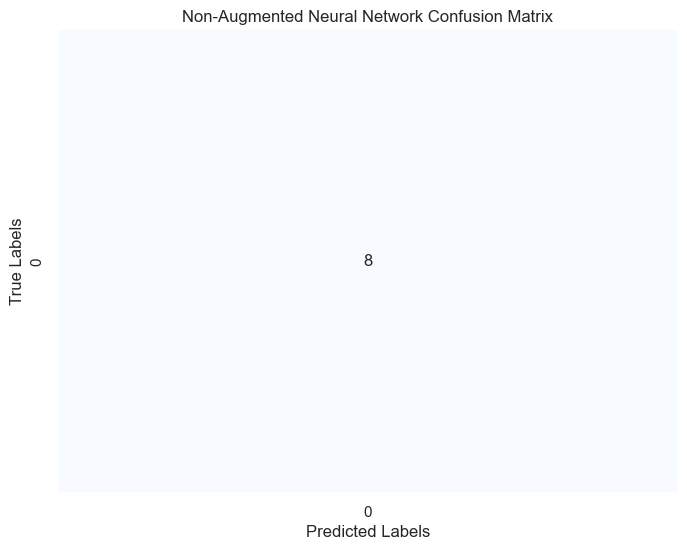


Sample 1 - True Labels: [270 913  14], Predictions: [0.2542945  0.4565867  0.28911886]

Sample 2 - True Labels: [167 367 107], Predictions: [0.37170008 0.39966664 0.2286333 ]

Sample 3 - True Labels: [447 949  32], Predictions: [0.18655708 0.61797005 0.19547282]

Sample 4 - True Labels: [237 701 109], Predictions: [0.29640877 0.4036644  0.2999268 ]

Sample 5 - True Labels: [188 275  17], Predictions: [0.34909898 0.39590687 0.2549941 ]


In [31]:
# Neural Network to predict the severity of accidents using the Main dataset (transport.csv) only
# NN Model1
# Define features and labels
X = transport_df.drop(['FATAL', 'SERIOUS', 'MINOR'], axis=1)
y = transport_df[['FATAL', 'SERIOUS', 'MINOR']]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 output neurons for FATAL, SERIOUS, and MINOR
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Make predictions on the test set
predictions = model.predict(X_test_scaled)

# Convert one-hot encoded predictions to categorical labels
y_pred_categorical = np.argmax(predictions, axis=1)
y_test_categorical = np.argmax(y_test.values, axis=1)

# Function to evaluate Neural Network model with metrics
def evaluate_nn(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=1)
    conf_matrix = confusion_matrix(y_true, y_pred)

    print(f"\n{model_name} Neural Network Evaluation:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("Confusion Matrix:")
    print(conf_matrix)
    
# Evaluate Neural Network
evaluate_nn(y_test_categorical, y_pred_categorical, 'Non-Augmented Neural Network')

# Visualize Confusion Matrix for Neural Network
conf_matrix_nn = confusion_matrix(y_test_categorical, y_pred_categorical)
plot_confusion(conf_matrix_nn, 'Non-Augmented Neural Network')

# Print sample predictions
for i in range(5):  # Print predictions for the first 5 samples
    print(f'\nSample {i + 1} - True Labels: {y_test.iloc[i].values}, Predictions: {predictions[i]}')

Epoch 1/50
1/1 [==============================] - 1s 1s/step - loss: 1176.6461 - accuracy: 0.5172 - val_loss: 1952.9077 - val_accuracy: 0.2500
Epoch 2/50
1/1 [==============================] - 0s 74ms/step - loss: 1153.2429 - accuracy: 0.5172 - val_loss: 1908.5571 - val_accuracy: 0.2500
Epoch 3/50
1/1 [==============================] - 0s 88ms/step - loss: 1132.6028 - accuracy: 0.5172 - val_loss: 1866.8477 - val_accuracy: 0.2500
Epoch 4/50
1/1 [==============================] - 0s 76ms/step - loss: 1113.4515 - accuracy: 0.5517 - val_loss: 1826.8470 - val_accuracy: 0.2500
Epoch 5/50
1/1 [==============================] - 0s 73ms/step - loss: 1096.5081 - accuracy: 0.5517 - val_loss: 1788.7429 - val_accuracy: 0.2500
Epoch 6/50
1/1 [==============================] - 0s 74ms/step - loss: 1081.9778 - accuracy: 0.5517 - val_loss: 1752.9355 - val_accuracy: 0.2500
Epoch 7/50
1/1 [==============================] - 0s 72ms/step - loss: 1068.9178 - accuracy: 0.5517 - val_loss: 1719.3916 - val_accu

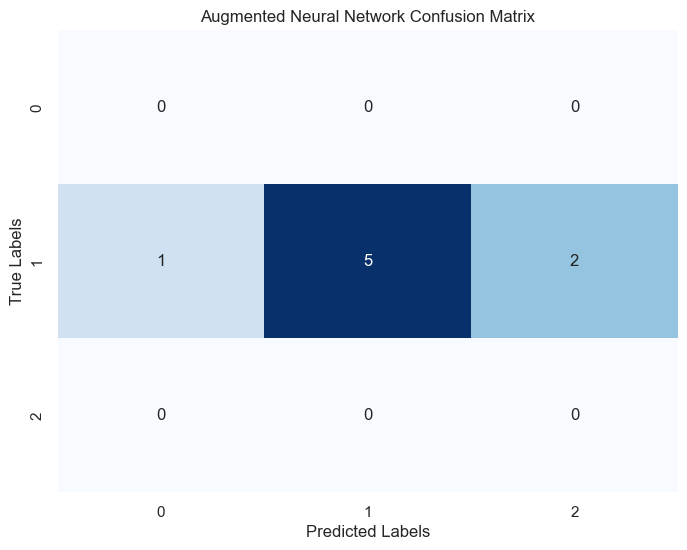


Sample 1 - True Labels: [270 913  14], Predictions: [0.12483671 0.34079072 0.53437257]

Sample 2 - True Labels: [167 367 107], Predictions: [0.298028   0.30318826 0.39878368]

Sample 3 - True Labels: [447 949  32], Predictions: [0.06941737 0.8441073  0.08647539]

Sample 4 - True Labels: [237 701 109], Predictions: [0.07537712 0.47892937 0.44569352]

Sample 5 - True Labels: [188 275  17], Predictions: [0.2986284  0.3868083  0.31456333]


In [30]:
# Tuning initial Neural Network to predict the severity of accidents 
# using the augmented merged dataset (transport.csv and caustivefactors.csv)
# NN tuned model

# One-hot encode the severity labels
labels = merged_data[['FATAL', 'SERIOUS', 'MINOR']]
y = pd.get_dummies(labels)

# Define features
X = merged_data.drop(['FATAL', 'SERIOUS', 'MINOR'], axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build the neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(3, activation='softmax')  # 3 output neurons for FATAL, SERIOUS, and MINOR
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_test_scaled, y_test))

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'\nTest Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy * 100:.2f}%')

# Make predictions on the test set
predictions = model.predict(X_test_scaled)

# Convert one-hot encoded predictions to categorical labels
y_pred_categorical = np.argmax(predictions, axis=1)
y_test_categorical = np.argmax(y_test.values, axis=1)

# Evaluate Neural Network
evaluate_nn(y_test_categorical, y_pred_categorical, 'Augmented Neural Network')

# Visualize Confusion Matrix for Neural Network
conf_matrix_nn = confusion_matrix(y_test_categorical, y_pred_categorical)
plot_confusion(conf_matrix_nn, 'Augmented Neural Network')

# Print sample predictions
for i in range(5):  # Print predictions for the first 5 samples
    print(f'\nSample {i + 1} - True Labels: {y_test.iloc[i].values}, Predictions: {predictions[i]}')